In [34]:
# a & e data are read in from .csv files

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ReadParticle import read_particle, read_particle_frames
from datetime import datetime, timedelta

# Read particle and collision data
#Np_seq, time, N_colDidy, N_colDimor, N_escape, r_dust, particle, data_c, data_p = read_particle('particles.txt', 'collide.txt')
Np_seq, time, r_dust, data_p = read_particle_frames('/home/linfel/rebound_exp/test_ejecta_180_datahigh/particles.txt')

/home/linfel/rebound_exp/test_ejecta_180_datahigh/particles.txt  processing completed!


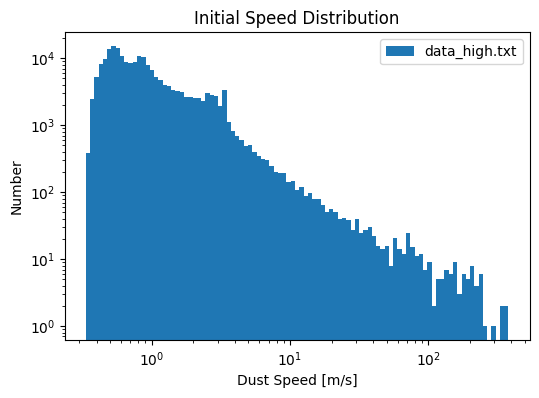

In [35]:
# initial speed histogram

p_t = data_p[0]
v_dust = p_t[4:, 4:7]
speed_dust = np.linalg.norm(v_dust, axis=1)

bins = np.logspace(np.log10(speed_dust.min()), np.log10(speed_dust.max()), num=100)

# plot all together
plt.figure(figsize=(6, 4))
counts, bin_edges = np.histogram(speed_dust, bins=bins)
plt.bar(bin_edges[:-1], counts, 
        width=bin_edges[1:] - bin_edges[:-1], 
        align='edge', 
        #edgecolor='black',
        label='data_high.txt'
       )

plt.xscale('log')
plt.yscale('log')


plt.xlabel('Dust Speed [m/s]')
plt.ylabel('Number')
plt.title('Initial Speed Distribution')
plt.legend()

output_name = "/home/linfel/rebound_exp/test_ejecta_180_datahigh/postprocess/initial_speed_histogram.png"
plt.savefig(output_name, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()
plt.close()

# Plotting histogram for eccentricity ...


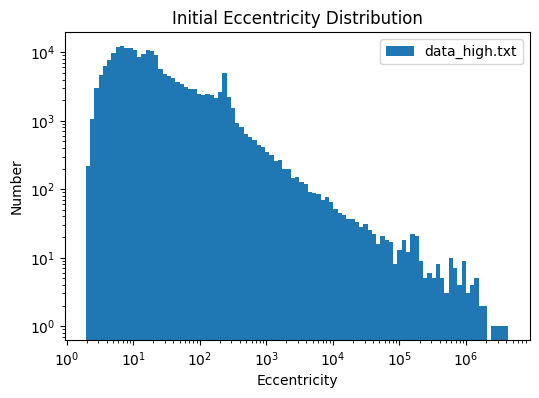

In [36]:
data_rootdir = "/home/linfel/rebound_exp/test_ejecta_180_datahigh"
data = np.genfromtxt(os.path.join(data_rootdir, "a_e_t0.csv"), delimiter=',', skip_header=1)

output_dir = os.path.join(data_rootdir, "postprocess")
os.makedirs(output_dir, exist_ok=True)

# Eccentricity histogram

print("# Plotting histogram for eccentricity ...",flush=True)
e_p = data[4:, 2]
bins = np.logspace(np.log10(e_p.min()), np.log10(e_p.max()), num=100)  # set bins for eccentricity

# plot all together
plt.figure(figsize=(6,4))
counts, bin_edges = np.histogram(e_p, bins=bins)
plt.bar(bin_edges[:-1], counts, width=bin_edges[1:] - bin_edges[:-1], align='edge', label='data_high.txt')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Eccentricity')
plt.ylabel('Number')
plt.title('Initial Eccentricity Distribution')
plt.legend()

plt.savefig(os.path.join(output_dir, "eccentricity.png"), dpi=300,bbox_inches='tight',pad_inches=0.1)
plt.show()
plt.close()

In [14]:
# Constants
G = 6.6743e-11
mass_system = 5.5e11
sep_system = 1170.0
mu_system = 6.6743e-11 * 5.5e11
vol_didy = 0.2295409644951028e9
vol_dimor = 0.001830603200702610e9
mass_didy = mass_system * vol_didy / (vol_didy + vol_dimor)
mass_dimor = mass_system * vol_dimor / (vol_didy + vol_dimor)

r_dimor_com = vol_didy*sep_system/(vol_didy+vol_dimor)
v_dimor_com = -np.sqrt(G*mass_didy/sep_system**2*r_dimor_com)
v_dimor_com

-0.17572821136485348

# Plotting ejecta type ...


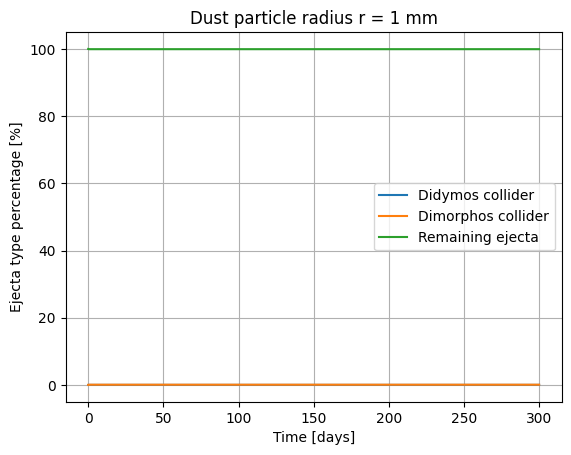

# Ejecta type completed!



In [2]:
# Plotting ejecta type
if (1):
    print("# Plotting ejecta type ...",flush=True)
    plt.figure()
    plt.plot(np.append(np.insert(N_colDidy[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDidy[:,1],0,0),N_colDidy[-1,1]) / Np_seq[0] * 100,
             label='Didymos collider', linewidth=1.5)
    plt.plot(np.append(np.insert(N_colDimor[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDimor[:,1],0,0),N_colDimor[-1,1]) / Np_seq[0] * 100,
             label='Dimorphos collider', linewidth=1.5)
    # plt.plot(np.append(np.insert(N_escape[:,0],0,0),time[-1]) / 24 / 3600,
    #          np.append(np.insert(N_escape[:,1],0,0),N_escape[-1,1]) / Np_seq[0] * 100,
    #          label='Escaped ejecta', linewidth=1.5)
    #plt.plot(np.insert(time_sort, 0, 0) / 24 / 3600, np.insert(N_sort, 0, 0) / Np_seq[0] * 100, label='Escaped ejecta', linewidth=1.5)
    plt.plot(time / 24 / 3600,
             Np_seq / Np_seq[0] * 100,
             label='Remaining ejecta', linewidth=1.5)
    plt.xlabel('Time [days]')
    plt.ylabel('Ejecta type percentage [%]')
    plt.title('Dust particle radius r = 1 mm')
    plt.legend()
    plt.grid()
    plt.savefig('ejecta_type.png',dpi=300)
    plt.show()
    plt.close()
    print("# Ejecta type completed!\n",flush=True)

# Plotting Dimorphos orbit ...


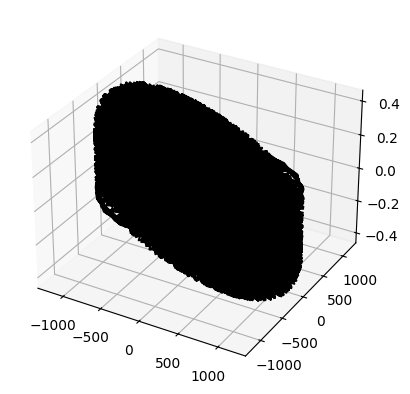

# Dimorphos orbit completed!



In [8]:
# Dimorphos orbit
if (1):
    print("# Plotting Dimorphos orbit ...",flush=True)
    didy_pos  = particle[0]['pos']
    dimor_pos = particle[1]['pos']
    n_p = 10
    np_pos    = particle[n_p]['pos']

    plt.figure().add_subplot(projection='3d')
    plt.plot(dimor_pos[:, 0] - didy_pos[:, 0],
             dimor_pos[:, 1] - didy_pos[:, 1],
             dimor_pos[:, 2] - didy_pos[:, 2], 
             label = 'Dimorphos orbit', linewidth=1.5, color='k')
    #plt.plot(np_pos[:, 0] - didy_pos[0:len(np_pos), 0],
    #         np_pos[:, 1] - didy_pos[0:len(np_pos), 1],
    #         np_pos[:, 2] - didy_pos[0:len(np_pos), 2],
    #         label = f'particle {n_p} orbit', linewidth=1.5)
    plt.savefig('dimor_orbit.png',dpi=300)
    plt.show()
    plt.close()
    print("# Dimorphos orbit completed!\n",flush=True)

In [123]:
"""phase angle analysis"""

import os
from multiprocessing import Pool
import numpy as np
from frame_renderer import init_worker, render_phase_angle_histogram

# Ensure output directory exists for saving frames
output_dir = "phase_angle"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)

if __name__ == "__main__": 
    # Render frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, 0, output_dir)) as pool:
        pool.map(render_phase_angle_histogram, range(num_frames))
    print(f"Frames rendered and saved in {output_dir}.")

Frames rendered and saved in phase_angle. 1847...dering phase angle histogram for frame 8...Rendering phase angle histogram for frame 16...Rendering phase angle histogram for frame 32...Rendering phase angle histogram for frame 24...Rendering phase angle histogram for frame 40...Rendering phase angle histogram for frame 48...Rendering phase angle histogram for frame 56...Rendering phase angle histogram for frame 72...Rendering phase angle histogram for frame 64...Rendering phase angle histogram for frame 120...Rendering phase angle histogram for frame 104...Rendering phase angle histogram for frame 128...Rendering phase angle histogram for frame 136...Rendering phase angle histogram for frame 184...Rendering phase angle histogram for frame 168...Rendering phase angle histogram for frame 176...Rendering phase angle histogram for frame 200...Rendering phase angle histogram for frame 192...Rendering phase angle histogram for frame 232...Rendering phase angle histogram for frame 216...Rend

In [ ]:
# a & e analysis

# specify timeslices to be analyzed
orbit_files = ['a_e_t0.csv','a_e_t12969701.csv','a_e_t25920000.csv']

for ofile in orbit_files:
    # processing
    t = ofile.split('t')[1].replace('.csv','')
    ae_array = np.genfromtxt(ofile,delimiter=',',skip_header=1)
    num_rows = np.shape(ae_array)[0]
    # add a fate column to the array of a_e data
    fate_column = np.zeros(num_rows)
    for i in range(num_rows):
        p_id = int(ae_array[i,0])
        p_fate = particle[p_id-1]['id_collide']
        fate_column[i] = p_fate
    ae_array = np.column_stack((ae_array,fate_column))
    
    # select rows of the three main bodies and dust particles
    p0 = ae_array[0]    # the row  of Didymos        in ae_array
    p1 = ae_array[1]    # the row  of Dimorphos      in ae_array
    p2 = ae_array[2]    # the row  of Sun            in ae_array
    p_ae = ae_array[4:] # the rows of dust particles in ae_array

    # Scatter plot with eccentricity shown in color 
    if (1):
        print("# Plotting particle locations with eccentricity ...",flush=True)
        
        # select particles with limited eccentricity and spatial range
        data1 = p_ae[p_ae[:,2]<=10.,:] # select particles with eccentricity <= 5. Don't plot others
        data2 = data1[(data1[:, 5] >= -10) & (data1[:, 5] <= 10), :] # select particles located within certain z range. Don't plot others
        
        plt.figure()
        # plot Dimorphos (x,y)
        #plt.scatter(p0[3], p0[4], c='red', s=10, zorder=3)
        plt.scatter(p1[3], p1[4], c='red', s=8, zorder=3)
        # plot dust particles (x,y), color as eccentricity
        dust_sc = plt.scatter(data1[3:, 3], data1[3:, 4], c=data1[3:, 2], s=2, cmap='gist_rainbow')
        cb = plt.colorbar(dust_sc)
        cb.set_label(f'Eccentricity', fontsize=12)
        
        plt.xlabel('x / m')
        plt.ylabel('y / m')
        plt.axis('equal')
        plt.title(f't = {t} s')
        plt.grid()
        plt.savefig(f'location_e_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Plotting particle locations with eccentricity completed!\n",flush=True)
    
    # Dust fate distribution in a and e space
    if (1):
        print("# Plotting dust fate distribution in a and e space ...",flush=True)
        plt.figure(figsize=(6,4))
        if p_ae[p_ae[:,-1] == 0].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 0,2], p_ae[p_ae[:,-1] == 0,1], s=5, label='Remaining')
        if p_ae[p_ae[:,-1] == 1].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 1,2], p_ae[p_ae[:,-1] == 1,1], s=5, label='Didy_col')
        if p_ae[p_ae[:,-1] == 2].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 2,2], p_ae[p_ae[:,-1] == 2,1], s=5, label='Dimor_col')
        if p_ae[p_ae[:,-1] == 3].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 3,2], p_ae[p_ae[:,-1] == 3,1], s=5, label='Escaped')
        #plt.title('Dust particle radius r = 1 mm')
        plt.xlabel('Eccentricity',size=12)
        plt.ylabel('Semimajor axis [m]',size=12)
        plt.legend(fontsize=10)
        plt.savefig(f'dustfate_ae_{t}s.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Dust fate distribution in a and e space completed!\n",flush=True)

    # Histogram for semi-major axis
    if (1):
        print("# Plotting histogram for semimajor axis ...",flush=True)
        bins = np.linspace(-100,11000,112)  # set bins for semimajor axis
        yscale_type = 'log'

        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,1], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Semimajor axis [m]')
        plt.ylabel('Number')
        plt.savefig(f'semimajor_axis_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))
        
        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,1], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,1], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,1], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,1], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Semimajor axis [m]' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'semimajor_axis_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for semimajor axis completed!\n",flush=True)

    # Histogram for eccentricity
    if (1):
        print("# Plotting histogram for eccentricity ...",flush=True)
        bins = np.linspace(-1,20,150)  # set bins for eccentricity
        yscale_type = 'log'
        
        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,2], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Eccentricity')
        plt.ylabel('Number')
        plt.savefig(f'eccentricity_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))

        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,2], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,2], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,2], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,2], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Eccentricity' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'eccentricity_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for eccentricity completed!\n",flush=True)